<a href="https://colab.research.google.com/github/parth-4895/Machine-Learning/blob/main/FeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('/content/kc_house_data.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [6]:
df["date_parsed_dayfirst"]=pd.to_datetime(df["date"], dayfirst=False, errors= "coerce")

In [7]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014-10-13
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014-12-09
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015-02-25
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014-12-09
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015-02-18


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    21613 non-null  int64         
 1   date                  21613 non-null  object        
 2   price                 21613 non-null  float64       
 3   bedrooms              21613 non-null  int64         
 4   bathrooms             21613 non-null  float64       
 5   sqft_living           21613 non-null  int64         
 6   sqft_lot              21613 non-null  int64         
 7   floors                21613 non-null  float64       
 8   waterfront            21613 non-null  int64         
 9   view                  21613 non-null  int64         
 10  condition             21613 non-null  int64         
 11  grade                 21613 non-null  int64         
 12  sqft_above            21613 non-null  int64         
 13  sqft_basement   

In [9]:
df["year"]=df["date_parsed_dayfirst"].dt.year.astype("Int32")

In [10]:
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year
6583,8562720420,20150430T000000,1349000.0,4,3.50,4740,8611,2.0,0,3,...,1100,2006,0,98027,47.5375,-122.070,4042,8321,2015-04-30,2015
7590,8121100147,20140714T000000,390000.0,3,2.25,1640,2875,2.0,0,0,...,400,1983,0,98118,47.5686,-122.286,1500,3960,2014-07-14,2014
11998,2068000270,20140805T000000,1400000.0,5,3.00,3850,14990,1.0,0,0,...,1560,1964,0,98004,47.6425,-122.218,3010,15001,2014-08-05,2014
18744,582000065,20141125T000000,725000.0,4,1.75,2700,6000,1.0,0,0,...,1250,1953,0,98199,47.6539,-122.395,2080,6000,2014-11-25,2014
13332,9274202620,20140718T000000,678100.0,3,1.75,1850,2860,1.5,0,0,...,640,1931,0,98116,47.5853,-122.390,1660,3120,2014-07-18,2014
21275,8725950170,20150123T000000,950000.0,2,2.25,2200,2043,2.0,0,0,...,440,2007,0,98004,47.6213,-122.200,2020,1957,2015-01-23,2015
17844,9528105305,20150121T000000,1375000.0,4,3.50,3130,4500,2.0,0,0,...,1070,2014,0,98103,47.6770,-122.330,1500,4500,2015-01-21,2015
11011,2597530070,20150318T000000,850000.0,3,2.50,2940,10809,2.0,0,0,...,0,1992,0,98006,47.5418,-122.136,3090,10348,2015-03-18,2015
20879,2895800610,20140926T000000,352800.0,4,2.25,1800,2752,2.0,0,0,...,0,2014,0,98106,47.5167,-122.346,1650,2752,2014-09-26,2014
6774,1025059181,20140722T000000,480000.0,3,2.00,1580,7400,1.0,0,0,...,530,1977,0,98052,47.6715,-122.162,1560,7458,2014-07-22,2014


In [11]:
df["bathrooms"]=df["bathrooms"].astype("Int32", errors="ignore")
df["floors"]=df["floors"].astype("Int32", errors="ignore")

In [12]:
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year
11454,2719100240,20140519T000000,850000.0,4,3.50,2640,5900,2.0,0,2,...,0,1937,1998,98136,47.5421,-122.383,1700,5900,2014-05-19,2014
11357,2734100738,20141029T000000,246950.0,3,3.50,1790,1682,2.0,0,0,...,310,2006,0,98108,47.5420,-122.321,1150,4000,2014-10-29,2014
18667,3226049054,20141003T000000,526500.0,3,1.50,1310,7236,1.0,0,0,...,140,1928,0,98103,47.6944,-122.333,1680,8431,2014-10-03,2014
3237,2296500131,20141216T000000,739000.0,5,4.00,4660,9900,2.0,0,2,...,2060,1979,0,98056,47.5135,-122.200,3380,9900,2014-12-16,2014
12350,8964800860,20150209T000000,1650000.0,4,2.50,2780,11904,1.0,0,1,...,1050,1951,0,98004,47.6209,-122.216,3590,13860,2015-02-09,2015
13722,4039700870,20150219T000000,1160000.0,5,1.75,2870,9680,1.0,0,4,...,1430,1966,0,98008,47.6122,-122.111,2940,9729,2015-02-19,2015
217,1909600046,20140703T000000,445838.0,3,2.50,2250,5692,2.0,0,0,...,0,2000,0,98146,47.5133,-122.379,1320,5390,2014-07-03,2014
7982,123000110,20140930T000000,520000.0,2,1.00,910,5000,1.0,0,0,...,0,1924,0,98107,47.6733,-122.370,1050,5000,2014-09-30,2014
4353,9485750110,20140918T000000,366000.0,3,1.75,1680,6108,1.0,0,0,...,0,1989,0,98055,47.4501,-122.208,2220,5664,2014-09-18,2014
495,9828702519,20140512T000000,490000.0,2,2.50,1230,1391,2.0,0,0,...,360,2004,0,98112,47.6192,-122.301,1240,1350,2014-05-12,2014


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    21613 non-null  int64         
 1   date                  21613 non-null  object        
 2   price                 21613 non-null  float64       
 3   bedrooms              21613 non-null  int64         
 4   bathrooms             21613 non-null  float64       
 5   sqft_living           21613 non-null  int64         
 6   sqft_lot              21613 non-null  int64         
 7   floors                21613 non-null  float64       
 8   waterfront            21613 non-null  int64         
 9   view                  21613 non-null  int64         
 10  condition             21613 non-null  int64         
 11  grade                 21613 non-null  int64         
 12  sqft_above            21613 non-null  int64         
 13  sqft_basement   

In [14]:
df['bathrooms'] = np.floor(pd.to_numeric(df['bathrooms'], errors='coerce')).astype('Int32')

In [15]:
df.head(
)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year
0,7129300520,20141013T000000,221900.0,3,1,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014-10-13,2014
1,6414100192,20141209T000000,538000.0,3,2,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014-12-09,2014
2,5631500400,20150225T000000,180000.0,2,1,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015-02-25,2015
3,2487200875,20141209T000000,604000.0,4,3,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014-12-09,2014
4,1954400510,20150218T000000,510000.0,3,2,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015-02-18,2015


In [16]:
df['floors'] = np.floor(pd.to_numeric(df['floors'], errors='coerce')).astype('Int32')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    21613 non-null  int64         
 1   date                  21613 non-null  object        
 2   price                 21613 non-null  float64       
 3   bedrooms              21613 non-null  int64         
 4   bathrooms             21613 non-null  Int32         
 5   sqft_living           21613 non-null  int64         
 6   sqft_lot              21613 non-null  int64         
 7   floors                21613 non-null  Int32         
 8   waterfront            21613 non-null  int64         
 9   view                  21613 non-null  int64         
 10  condition             21613 non-null  int64         
 11  grade                 21613 non-null  int64         
 12  sqft_above            21613 non-null  int64         
 13  sqft_basement   

In [18]:
df["bedrooms"]=df["bedrooms"].astype("Int32")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    21613 non-null  int64         
 1   date                  21613 non-null  object        
 2   price                 21613 non-null  float64       
 3   bedrooms              21613 non-null  Int32         
 4   bathrooms             21613 non-null  Int32         
 5   sqft_living           21613 non-null  int64         
 6   sqft_lot              21613 non-null  int64         
 7   floors                21613 non-null  Int32         
 8   waterfront            21613 non-null  int64         
 9   view                  21613 non-null  int64         
 10  condition             21613 non-null  int64         
 11  grade                 21613 non-null  int64         
 12  sqft_above            21613 non-null  int64         
 13  sqft_basement   

In [20]:
df["bed&bathR"] = df["bedrooms"]+df["bathrooms"]

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    21613 non-null  int64         
 1   date                  21613 non-null  object        
 2   price                 21613 non-null  float64       
 3   bedrooms              21613 non-null  Int32         
 4   bathrooms             21613 non-null  Int32         
 5   sqft_living           21613 non-null  int64         
 6   sqft_lot              21613 non-null  int64         
 7   floors                21613 non-null  Int32         
 8   waterfront            21613 non-null  int64         
 9   view                  21613 non-null  int64         
 10  condition             21613 non-null  int64         
 11  grade                 21613 non-null  int64         
 12  sqft_above            21613 non-null  int64         
 13  sqft_basement   

In [22]:
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR
7685,1786810040,20140909T000000,698000.0,3,2,2640,11957,1,0,0,...,1978,0,98052,47.6491,-122.120,2640,12641,2014-09-09,2014,5
12146,4312700200,20140820T000000,195000.0,3,1,1300,9600,1,0,0,...,1975,0,98092,47.3037,-122.107,1150,10222,2014-08-20,2014,4
21462,5694000706,20140813T000000,535000.0,3,2,1320,1125,3,0,0,...,2008,0,98103,47.6598,-122.348,1320,1266,2014-08-13,2014,5
12769,7518505040,20150330T000000,415000.0,1,1,700,2550,1,0,0,...,1954,0,98117,47.6783,-122.383,1330,4110,2015-03-30,2015,2
15896,2131701410,20150427T000000,299950.0,3,2,1370,5000,2,0,0,...,1990,0,98019,47.7372,-121.981,1600,7724,2015-04-27,2015,5
5204,4048400185,20141022T000000,352000.0,2,0,760,33801,1,0,0,...,1931,0,98059,47.4703,-122.076,1100,39504,2014-10-22,2014,2
11716,705710640,20150302T000000,319950.0,3,2,1700,7000,2,0,0,...,1996,0,98038,47.3798,-122.025,1950,7000,2015-03-02,2015,5
15925,9460000010,20141203T000000,285000.0,3,1,1990,6500,1,0,0,...,1961,0,98055,47.4880,-122.221,2150,6500,2014-12-03,2014,4
2733,4406000560,20150220T000000,278500.0,4,1,1540,8400,1,0,0,...,1971,0,98058,47.4278,-122.152,1520,9891,2015-02-20,2015,5
12809,5089700720,20150127T000000,335000.0,4,2,2400,8592,2,0,0,...,1978,0,98055,47.4383,-122.193,2180,8100,2015-01-27,2015,6


In [23]:
df=df.set_index("id")

In [24]:
df = df.sort_index(ascending=True)

In [25]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR
id,,,,,,,,,,,,,,,,,,,,,
1000102,20150422T000000,300000.0,6,3,2400,9373,2,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,2015-04-22,2015,9
1000102,20140916T000000,280000.0,6,3,2400,9373,2,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,2014-09-16,2014,9
1200019,20140508T000000,647500.0,4,1,2060,26036,1,0,0,4,...,1947,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5
1200021,20140811T000000,400000.0,3,1,1460,43000,1,0,0,3,...,1952,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4
2800031,20150401T000000,235000.0,3,1,1430,7599,1,0,0,4,...,1930,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,20140725T000000,365000.0,5,2,1600,4168,1,0,0,3,...,1927,0,98126,47.5297,-122.381,1190,4168,2014-07-25,2014,7
9842300485,20150311T000000,380000.0,2,1,1040,7372,1,0,0,5,...,1939,0,98126,47.5285,-122.378,1930,5150,2015-03-11,2015,3
9842300540,20140624T000000,339000.0,3,1,1100,4128,1,0,0,4,...,1942,0,98126,47.5296,-122.379,1510,4538,2014-06-24,2014,4


In [26]:
df.groupby("zipcode")

In [27]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR
id,,,,,,,,,,,,,,,,,,,,,
1000102,20150422T000000,300000.0,6,3,2400,9373,2,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,2015-04-22,2015,9
1000102,20140916T000000,280000.0,6,3,2400,9373,2,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,2014-09-16,2014,9
1200019,20140508T000000,647500.0,4,1,2060,26036,1,0,0,4,...,1947,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5
1200021,20140811T000000,400000.0,3,1,1460,43000,1,0,0,3,...,1952,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4
2800031,20150401T000000,235000.0,3,1,1430,7599,1,0,0,4,...,1930,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,20140725T000000,365000.0,5,2,1600,4168,1,0,0,3,...,1927,0,98126,47.5297,-122.381,1190,4168,2014-07-25,2014,7
9842300485,20150311T000000,380000.0,2,1,1040,7372,1,0,0,5,...,1939,0,98126,47.5285,-122.378,1930,5150,2015-03-11,2015,3
9842300540,20140624T000000,339000.0,3,1,1100,4128,1,0,0,4,...,1942,0,98126,47.5296,-122.379,1510,4538,2014-06-24,2014,4


In [28]:
df["fraction_of_living"]= df["sqft_living"]/df["sqft_lot"]

In [29]:
df["fraction_of_living"].describe(

)

,fraction_of_living
count,21613.000000
mean,0.323745
std,0.268565
min,0.000610
25%,0.156581
50%,0.247664
75%,0.407547
max,4.653846


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df['price'].corr(df['fraction_of_living'], method="pearson")

np.float64(0.12311493581273028)

In [32]:
df['price'].corr(df['sqft_living'], method="pearson")

np.float64(0.7020350546118002)

In [33]:
df['price'].corr(df['sqft_lot'], method="pearson")

np.float64(0.08966086058710007)

This indicates that the price of a house depends only on the toal living space that it contains. It has weak relation to the total landspace that it contains. It has weak relation also with the fraction of the living space to the toal landspace altough that relation was stronger than the relation to the total land space

In [34]:
df['price'].corr(df['bed&bathR'], method="pearson")

np.float64(0.4627701482038656)

In [35]:
df['price'].corr(df['bedrooms'], method="pearson")

np.float64(0.3083495981456381)

In [36]:
df['bedrooms'].corr(df['bathrooms'], method="pearson")

np.float64(0.4674521494342316)

Here as the corr decreases on merging the two columns, predictive strength is lost, hence we will not merge the columns and keep them separate
But then is the bedrooms column of any importance? I think it is as the number of bedrooms is always a defining feature for any plot that is livable

In [37]:
df['bedrooms'].corr(df['floors'], method="pearson")

np.float64(0.15564332953123047)

In [38]:
df['price'].corr(df['lat'], method="pearson")

np.float64(0.30700347999521865)

In [39]:
df['price'].corr(df['long'], method="pearson")

np.float64(0.021626241039306694)

<Axes: xlabel='lat', ylabel='price'>

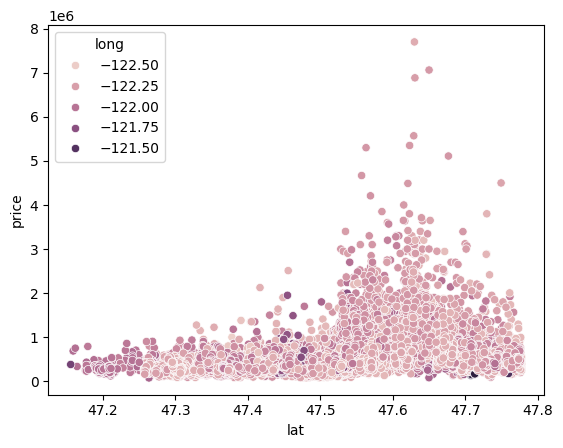

In [40]:
sns.scatterplot(df, x="lat", y="price", hue="long")

There is not a strong linear relationship but we can see that as the latitude increases, there are houses for which price is high. On lower lats, the price for houses is always low. We also have more outliers for higher lats. Is this due to the temperature being cold there?

In [41]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living
id,,,,,,,,,,,,,,,,,,,,,
1000102,20150422T000000,300000.0,6,3,2400,9373,2,0,0,3,...,0,98002,47.3262,-122.214,2060,7316,2015-04-22,2015,9,0.256055
1000102,20140916T000000,280000.0,6,3,2400,9373,2,0,0,3,...,0,98002,47.3262,-122.214,2060,7316,2014-09-16,2014,9,0.256055
1200019,20140508T000000,647500.0,4,1,2060,26036,1,0,0,4,...,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121
1200021,20140811T000000,400000.0,3,1,1460,43000,1,0,0,3,...,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953
2800031,20150401T000000,235000.0,3,1,1430,7599,1,0,0,4,...,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183


In [42]:
df["date"]=df["date_parsed_dayfirst"]

In [43]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living
id,,,,,,,,,,,,,,,,,,,,,
1000102,2015-04-22,300000.0,6,3,2400,9373,2,0,0,3,...,0,98002,47.3262,-122.214,2060,7316,2015-04-22,2015,9,0.256055
1000102,2014-09-16,280000.0,6,3,2400,9373,2,0,0,3,...,0,98002,47.3262,-122.214,2060,7316,2014-09-16,2014,9,0.256055
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183


(-1.0, 12.0)

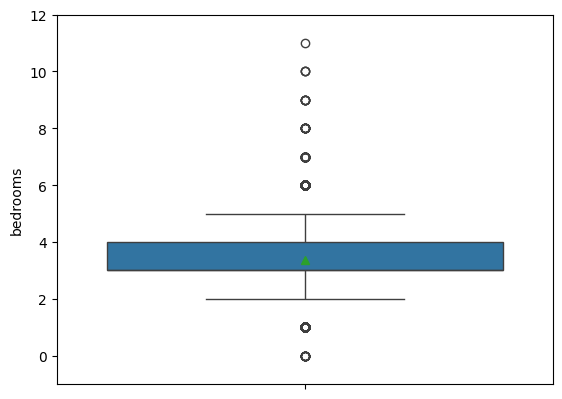

In [44]:
sns.boxplot(data=df,y="bedrooms", showmeans=True)
plt.ylim(-1,12)

In [45]:
df["bedrooms"].describe()

,bedrooms
count,21613.0
mean,3.370842
std,0.930062
min,0.0
25%,3.0
50%,3.0
75%,4.0
max,33.0


(-1.0, 12.0)

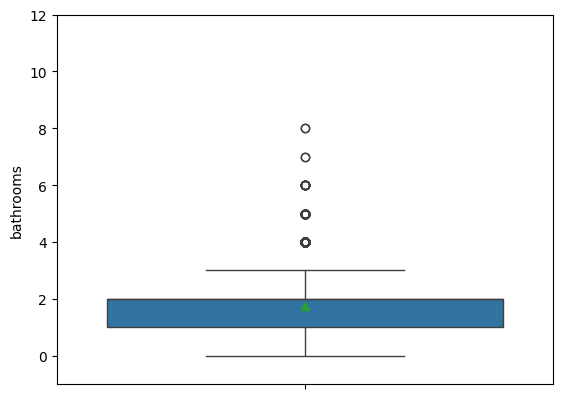

In [46]:
sns.boxplot(data=df,y="bathrooms", showmeans=True)
plt.ylim(-1,12)

In [47]:
df["bathrooms"].describe()

,bathrooms
count,21613.0
mean,1.749734
std,0.734873
min,0.0
25%,1.0
50%,2.0
75%,2.0
max,8.0


In [48]:
df = df[(df['bedrooms'] > 1) & (df['bedrooms'] < 6)]

In [49]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183
3600057,2015-03-19,402500.0,4,2,1650,3504,1,0,0,3,...,2013,98144,47.5803,-122.294,1480,3504,2015-03-19,2015,6,0.470890
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,0,98144,47.5801,-122.294,1540,4200,2015-03-30,2015,6,0.418079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,2014-07-25,365000.0,5,2,1600,4168,1,0,0,3,...,0,98126,47.5297,-122.381,1190,4168,2014-07-25,2014,7,0.383877
9842300485,2015-03-11,380000.0,2,1,1040,7372,1,0,0,5,...,0,98126,47.5285,-122.378,1930,5150,2015-03-11,2015,3,0.141074
9842300540,2014-06-24,339000.0,3,1,1100,4128,1,0,0,4,...,0,98126,47.5296,-122.379,1510,4538,2014-06-24,2014,4,0.266473


(-1.0, 12.0)

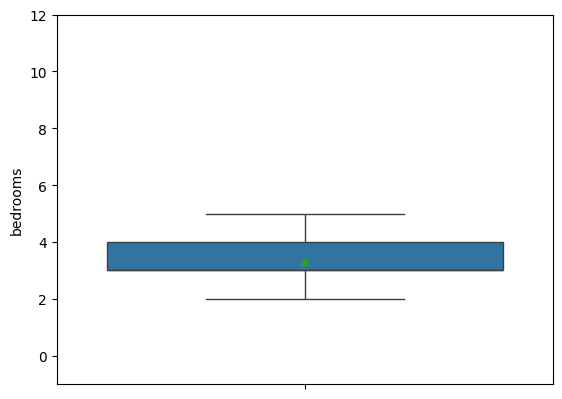

In [50]:
sns.boxplot(data=df,y="bedrooms", showmeans=True)
plt.ylim(-1,12)

In [51]:
df['price'].corr(df['bedrooms'], method="pearson")

np.float64(0.3084914290506788)

### The Impact of Outliers on Correlation

Outliers are data points that significantly differ from other observations. When calculating Pearson correlation, which measures the linear relationship between two variables, these extreme values can heavily influence the result.

*   **Inflated Correlation**: An outlier can create a false impression of a strong linear relationship where there isn't one for the bulk of the data.
*   **Deflated Correlation**: Conversely, an outlier can weaken an otherwise strong linear relationship, or even flip the sign of the correlation.

To understand the effect of outliers, it's often helpful to visualize the data with scatter plots. This allows you to visually identify points that might be skewing the correlation.

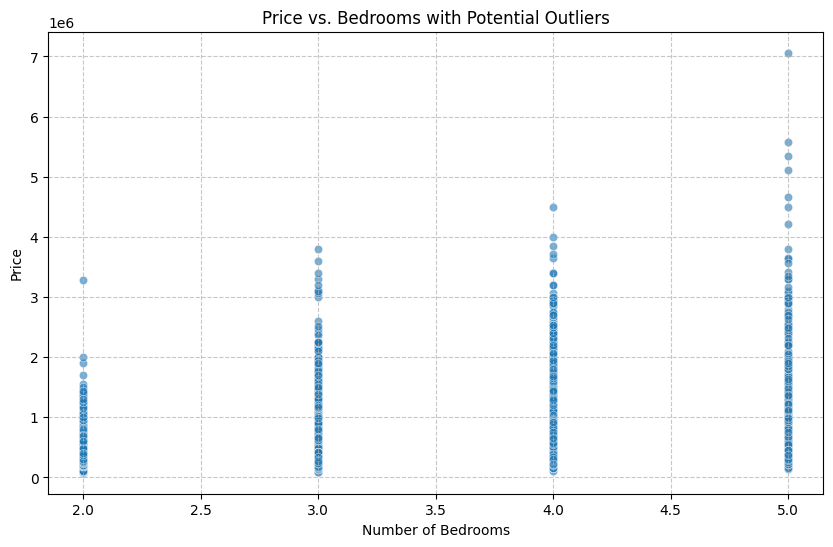

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bedrooms'], y=df['price'], alpha=0.6)
plt.title('Price vs. Bedrooms with Potential Outliers')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

As you can see from the scatter plot, there are houses with a very high number of bedrooms (up to 33) and houses with a very high price that might be considered outliers. These points can significantly influence the Pearson correlation coefficient. If you'd like to explore correlations that are less sensitive to outliers, we can use methods like Spearman's rank correlation, which assesses monotonic relationships without assuming linearity.

In [53]:
df['price'].corr(df['bedrooms'], method='spearman')

np.float64(0.33019026963052367)

In [54]:
# Calculate Q1, Q3, and IQR for 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out price outliers
initial_rows = df.shape[0]
df_filtered_price = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

rows_removed = initial_rows - df_filtered_price.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after removing price outliers: {df_filtered_price.shape[0]}")
print(f"Number of price outliers removed: {rows_removed}")

# Update the main DataFrame 'df' with the filtered data
df = df_filtered_price.copy()

Initial number of rows: 21067
Number of rows after removing price outliers: 19965
Number of price outliers removed: 1102


Now that we've removed the price outliers, let's re-calculate both the Pearson and Spearman correlations to observe the effect.

In [55]:
pearson_corr_after_price_outliers = df['price'].corr(df['bedrooms'], method='pearson')
spearman_corr_after_price_outliers = df['price'].corr(df['bedrooms'], method='spearman')

print(f"Pearson correlation after removing price outliers: {pearson_corr_after_price_outliers}")
print(f"Spearman correlation after removing price outliers: {spearman_corr_after_price_outliers}")

Pearson correlation after removing price outliers: 0.29390767210032476
Spearman correlation after removing price outliers: 0.29013535033500354


In [56]:
df['bedrooms'].corr(df['bathrooms'], method="pearson")

np.float64(0.4192846858262743)

In [57]:
df.sample(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living
id,,,,,,,,,,,,,,,,,,,,,
7853301400,2014-05-20,625000.0,4,2,3550,8048,2,0,0,3,...,0,98065,47.5422,-121.888,3920,7871,2014-05-20,2014,6,0.441103
1274500060,2014-08-25,204000.0,3,1,1000,12070,1,0,0,4,...,0,98042,47.3621,-122.110,1010,12635,2014-08-25,2014,4,0.082850
2551500220,2014-08-15,330000.0,3,1,1040,11900,1,0,0,5,...,0,98070,47.4332,-122.446,1250,9600,2014-08-15,2014,4,0.087395
8562780190,2014-10-07,315000.0,2,2,1240,705,2,0,0,3,...,0,98027,47.5321,-122.073,1240,750,2014-10-07,2014,4,1.758865
5029451080,2014-08-21,203000.0,2,1,1440,6650,1,0,0,3,...,0,98023,47.2896,-122.369,1600,6847,2014-08-21,2014,3,0.216541
458000065,2014-09-23,542000.0,4,2,2020,3440,1,0,0,4,...,0,98117,47.6885,-122.376,1520,5080,2014-09-23,2014,6,0.587209
5067400162,2015-02-18,290000.0,3,2,1550,18958,1,0,0,3,...,0,98198,47.3699,-122.319,1840,12826,2015-02-18,2015,5,0.081760
321049090,2014-06-26,254000.0,5,2,2080,16117,1,0,0,5,...,0,98001,47.3424,-122.289,1510,13068,2014-06-26,2014,7,0.129056
509000020,2014-11-18,510000.0,3,2,2540,40106,2,0,0,3,...,0,98074,47.6037,-122.043,3190,71797,2014-11-18,2014,5,0.063332


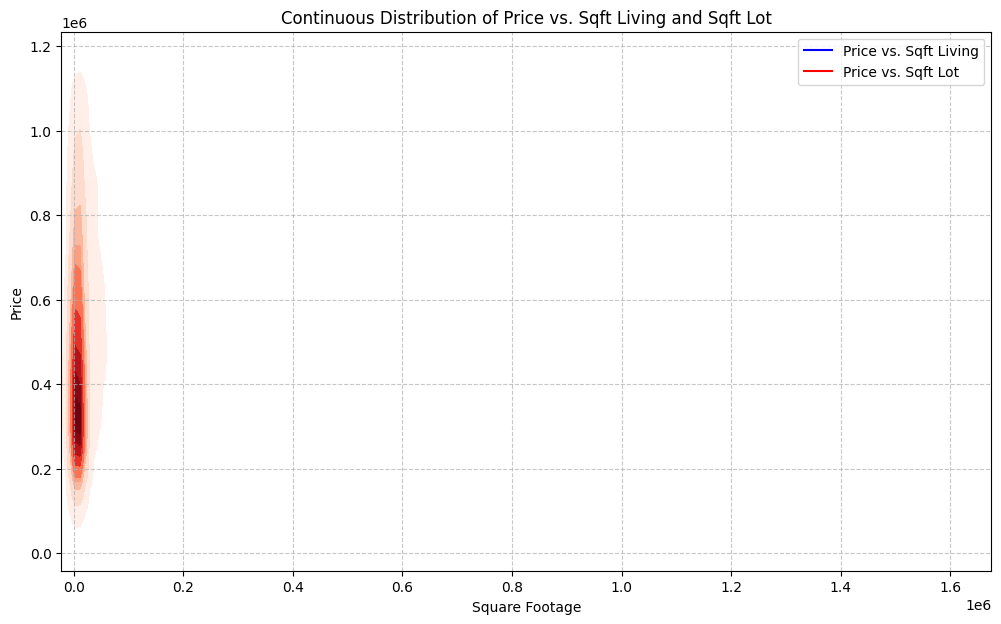

In [58]:
plt.figure(figsize=(12, 7))
sns.kdeplot(x=df['sqft_living'], y=df['price'], cmap='Blues', fill=True, levels=10)
sns.kdeplot(x=df['sqft_lot'], y=df['price'], cmap='Reds', fill=True, levels=10)

# Create dummy plots to generate legend handles
plt.plot([], [], color='blue', label='Price vs. Sqft Living')
plt.plot([], [], color='red', label='Price vs. Sqft Lot')

plt.title('Continuous Distribution of Price vs. Sqft Living and Sqft Lot')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

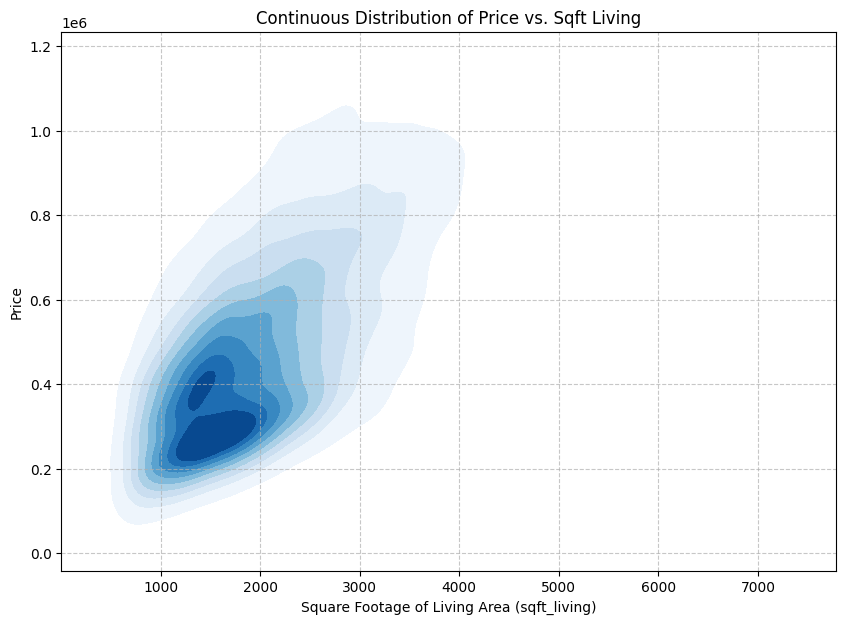

In [59]:
plt.figure(figsize=(10, 7))
sns.kdeplot(x=df['sqft_living'], y=df['price'], cmap='Blues', fill=True, levels=10)
plt.title('Continuous Distribution of Price vs. Sqft Living')
plt.xlabel('Square Footage of Living Area (sqft_living)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

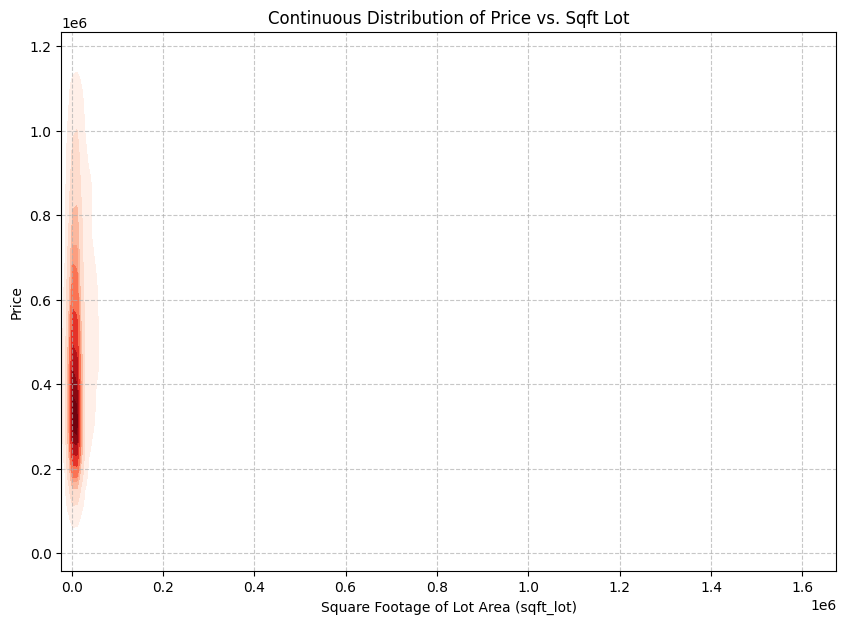

In [60]:
plt.figure(figsize=(10, 7))
sns.kdeplot(x=df['sqft_lot'], y=df['price'], cmap='Reds', fill=True, levels=10)
plt.title('Continuous Distribution of Price vs. Sqft Lot')
plt.xlabel('Square Footage of Lot Area (sqft_lot)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

You should now see two distinct plots:

1.  **Price vs. Sqft Living:** This plot shows the density of houses based on their living area and price. You'll likely observe a strong concentration along an upward-sloping diagonal, indicating that larger living areas are generally associated with higher prices.
2.  **Price vs. Sqft Lot:** This plot shows the density for lot area and price. The distribution here might be more spread out, and the relationship might appear less linear or concentrated compared to `sqft_living`, suggesting that while lot size plays a role, its influence on price might be less direct or more varied than the living area.

These plots show how sqft_lot is almost independent with price. The relationship is quite weak. So we will not use this variable for further analysis realted to price

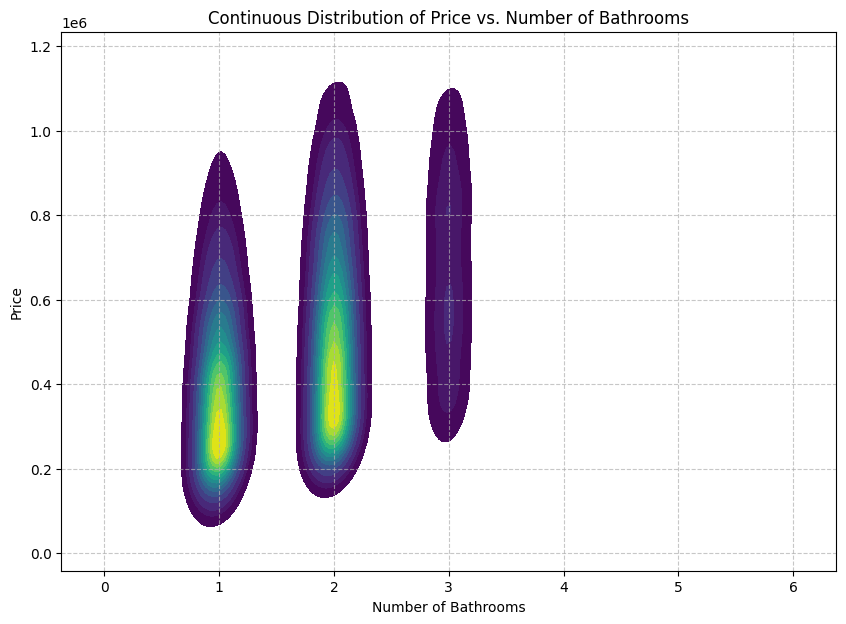

In [61]:
plt.figure(figsize=(10, 7))
sns.kdeplot(x=df["bathrooms"], y=df["price"], cmap='viridis', fill=True, levels=15)
plt.title('Continuous Distribution of Price vs. Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Does this mean that there are many houses with the number of bathrooms 1 and 2 but we can find only some houses with 3 bathrooms for any price.

In [62]:
df.head(

)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,0,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,0,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,0,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183
3600057,2015-03-19,402500.0,4,2,1650,3504,1,0,0,3,...,2013,98144,47.5803,-122.294,1480,3504,2015-03-19,2015,6,0.470890
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,0,98144,47.5801,-122.294,1540,4200,2015-03-30,2015,6,0.418079


In [63]:
df["renovated"]=df["yr_renovated"]>0

In [64]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,zipcode,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living,renovated
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,98166,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121,False
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,98166,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953,False
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,98168,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183,False
3600057,2015-03-19,402500.0,4,2,1650,3504,1,0,0,3,...,98144,47.5803,-122.294,1480,3504,2015-03-19,2015,6,0.470890,True
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,98144,47.5801,-122.294,1540,4200,2015-03-30,2015,6,0.418079,False


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19965 entries, 1200019 to 9900000190
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  19965 non-null  datetime64[ns]
 1   price                 19965 non-null  float64       
 2   bedrooms              19965 non-null  Int32         
 3   bathrooms             19965 non-null  Int32         
 4   sqft_living           19965 non-null  int64         
 5   sqft_lot              19965 non-null  int64         
 6   floors                19965 non-null  Int32         
 7   waterfront            19965 non-null  int64         
 8   view                  19965 non-null  int64         
 9   condition             19965 non-null  int64         
 10  grade                 19965 non-null  int64         
 11  sqft_above            19965 non-null  int64         
 12  sqft_basement         19965 non-null  int64         
 13  yr_built  

In [66]:
df["age"]=df["year"]-df["yr_built"]

<Axes: xlabel='age', ylabel='price'>

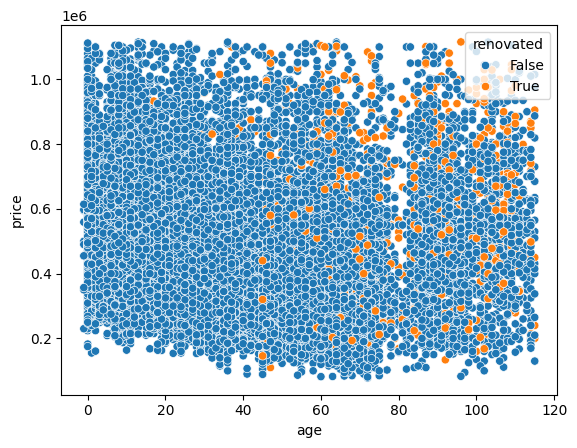

In [67]:
sns.scatterplot(data=df,x="age", y="price", hue="renovated")

In [68]:
df["price"].corr(df["age"])

np.float64(-0.059552232877640936)

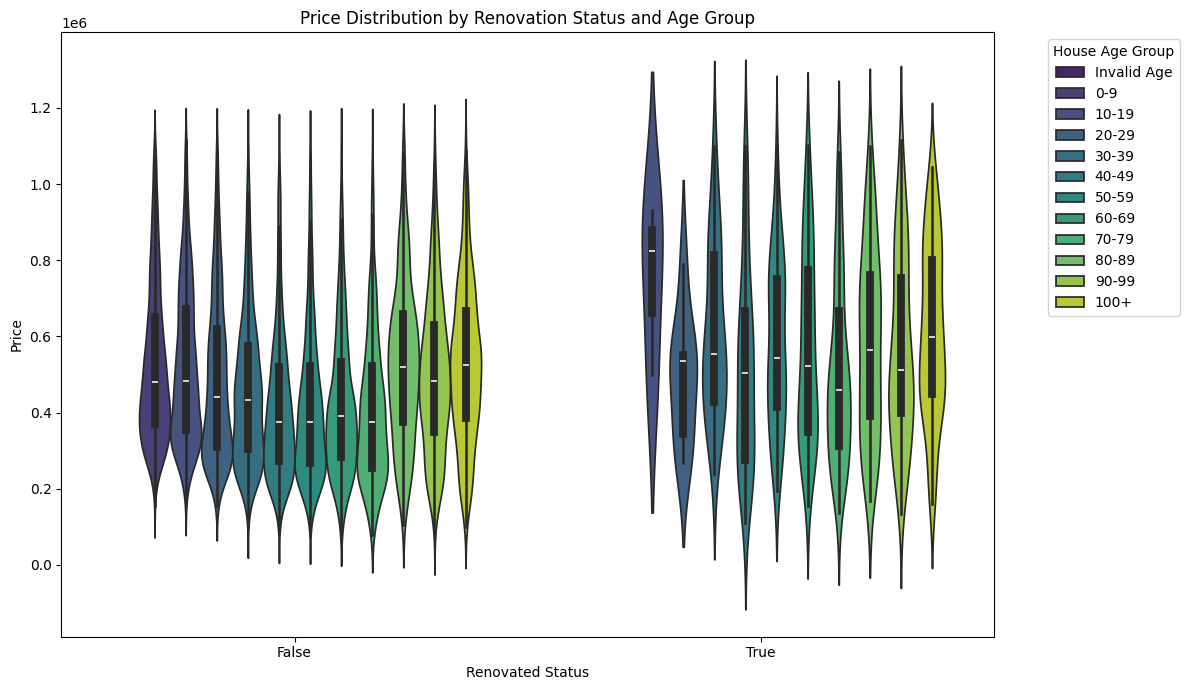

In [69]:
# Create a copy of the DataFrame for plotting to avoid modifying the original 'df' with temporary columns
df_for_plot = df.copy()

# Handle potential negative ages by setting them to 0 for the purpose of binning
df_for_plot['age_for_binning'] = df_for_plot['age'].apply(lambda x: max(x, 0))

# Define age bins and labels
bins = [-1, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, df_for_plot['age_for_binning'].max() + 1]
labels = ['Invalid Age', '0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df_for_plot['age_group'] = pd.cut(df_for_plot['age_for_binning'], bins=bins, labels=labels, right=False, include_lowest=True)

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_for_plot, x="renovated", y="price", hue="age_group", palette="viridis")
plt.title('Price Distribution by Renovation Status and Age Group')
plt.xlabel('Renovated Status')
plt.ylabel('Price')
plt.legend(title='House Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
df_for_plot

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living,renovated,age,age_for_binning,age_group
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,2590,21891,2014-05-08,2014,5,0.079121,False,67,67,60-69
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,2250,20023,2014-08-11,2014,4,0.033953,False,62,62,60-69
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,1290,10320,2015-04-01,2015,4,0.188183,False,85,85,80-89
3600057,2015-03-19,402500.0,4,2,1650,3504,1,0,0,3,...,1480,3504,2015-03-19,2015,6,0.470890,True,64,64,60-69
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,1540,4200,2015-03-30,2015,6,0.418079,False,64,64,60-69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,2014-07-25,365000.0,5,2,1600,4168,1,0,0,3,...,1190,4168,2014-07-25,2014,7,0.383877,False,87,87,80-89
9842300485,2015-03-11,380000.0,2,1,1040,7372,1,0,0,5,...,1930,5150,2015-03-11,2015,3,0.141074,False,76,76,70-79
9842300540,2014-06-24,339000.0,3,1,1100,4128,1,0,0,4,...,1510,4538,2014-06-24,2014,4,0.266473,False,72,72,70-79


In [71]:
df_for_plot.groupby("age_group")["renovated"].value_counts()

/tmp/ipykernel_3640/1754249649.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_for_plot.groupby("age_group")["renovated"].value_counts()


age_group    renovated
Invalid Age  False           0
             True            0
0-9          False        2758
             True            0
10-19        False        2482
             True            3
20-29        False        2313
             True            8
30-39        False        2407
             True           31
40-49        False        1950
             True           60
50-59        False        2199
             True           75
60-69        False        1919
             True          128
70-79        False         970
             True          103
80-89        False         728
             True           80
90-99        False         724
             True           96
100+         False         787
             True          144
Name: count, dtype: int64

In [72]:
df_for_nonren = df[df["renovated"]==False]

In [73]:
df_for_nonren

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living,renovated,age
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121,False,67
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953,False,62
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183,False,85
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,47.5801,-122.294,1540,4200,2015-03-30,2015,6,0.418079,False,64
3800008,2015-02-24,178000.0,5,1,1990,18200,1,0,0,3,...,47.4938,-122.262,1860,8658,2015-02-24,2015,6,0.109341,False,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,2014-07-25,365000.0,5,2,1600,4168,1,0,0,3,...,47.5297,-122.381,1190,4168,2014-07-25,2014,7,0.383877,False,87
9842300485,2015-03-11,380000.0,2,1,1040,7372,1,0,0,5,...,47.5285,-122.378,1930,5150,2015-03-11,2015,3,0.141074,False,76
9842300540,2014-06-24,339000.0,3,1,1100,4128,1,0,0,4,...,47.5296,-122.379,1510,4538,2014-06-24,2014,4,0.266473,False,72


In [74]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,date_parsed_dayfirst,year,bed&bathR,fraction_of_living,renovated,age
id,,,,,,,,,,,,,,,,,,,,,
1200019,2014-05-08,647500.0,4,1,2060,26036,1,0,0,4,...,47.4444,-122.351,2590,21891,2014-05-08,2014,5,0.079121,False,67
1200021,2014-08-11,400000.0,3,1,1460,43000,1,0,0,3,...,47.4434,-122.347,2250,20023,2014-08-11,2014,4,0.033953,False,62
2800031,2015-04-01,235000.0,3,1,1430,7599,1,0,0,4,...,47.4783,-122.265,1290,10320,2015-04-01,2015,4,0.188183,False,85
3600057,2015-03-19,402500.0,4,2,1650,3504,1,0,0,3,...,47.5803,-122.294,1480,3504,2015-03-19,2015,6,0.470890,True,64
3600072,2015-03-30,680000.0,4,2,2220,5310,1,0,0,5,...,47.5801,-122.294,1540,4200,2015-03-30,2015,6,0.418079,False,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9842300095,2014-07-25,365000.0,5,2,1600,4168,1,0,0,3,...,47.5297,-122.381,1190,4168,2014-07-25,2014,7,0.383877,False,87
9842300485,2015-03-11,380000.0,2,1,1040,7372,1,0,0,5,...,47.5285,-122.378,1930,5150,2015-03-11,2015,3,0.141074,False,76
9842300540,2014-06-24,339000.0,3,1,1100,4128,1,0,0,4,...,47.5296,-122.379,1510,4538,2014-06-24,2014,4,0.266473,False,72


In [77]:
X=df[["sqft_living","bathrooms","renovated"]]
y= df["price"]

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.75)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_new = scaler.fit_transform(X_train)
X_test_new = scaler.transform(X_test)
y_train_new = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_new = scaler.transform(y_test.values.reshape(-1, 1))

In [83]:
X_train

,sqft_living,bathrooms,renovated
id,,,
87000006,1680,1,False
3226059071,1130,1,False
3126049052,2040,1,False
3052700419,1350,2,False
2770604615,1640,2,False
...,...,...,...
8819900170,2520,2,False
6678900150,2240,2,False
8651440230,1670,2,False


In [84]:
X_train_new


array([[-0.38185111, -1.03992592, -0.19081128],
       [-1.10331495, -1.03992592, -0.19081128],
       [ 0.09037977, -1.03992592, -0.19081128],
       ...,
       [-0.39496863,  0.49067575, -0.19081128],
       [-0.5392614 , -1.03992592, -0.19081128],
       [-0.65731912, -1.03992592, -0.19081128]])

In [87]:
y_test_new

array([[-0.69167199],
       [ 0.56134685],
       [-0.34363813],
       ...,
       [ 2.41785058],
       [-0.38387046],
       [-0.56346175]])

In [88]:
y_train_new

array([[-0.97523719],
       [-0.24329968],
       [ 0.36260885],
       ...,
       [-1.1933691 ],
       [ 1.20118625],
       [-0.27771529]])

In [ ]:
np.hst